# Prueba Modelo SEGNET
Entrenamiento completo con métricas de evaluación

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm # para mostrar barras de progreso
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from segNet import SegNet

## Crear modelo

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.5.1+cu121
12.1
True


In [3]:
# Crear modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SegNet(in_channels=3, num_classes=2).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Modelo U-Net Base creado")
print(f"   Device: {device}")
print(f"   Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

Modelo U-Net Base creado
   Device: cuda
   Parámetros totales: 24,943,426
   Parámetros entrenables: 24,943,426


## Cargar datos de entrenamiento
(Data preprocesada)

In [4]:
import pickle

# Cargar el archivo
with open('data_minimal_filtrado.pkl', 'rb') as f:
    data = pickle.load(f)

In [5]:
from dataset_form import train_transform, val_transform, SimpleDataset

train_tiles = data['train']
val_tiles = data['val']
annotations_dict = data['annotations']

# Volver a construir datasets y loaders
train_dataset = SimpleDataset(train_tiles, '../train/', annotations_dict, train_transform)
val_dataset = SimpleDataset(val_tiles, '../train/', annotations_dict, val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=2, shuffle=False)

## Funciones de pérdida y métricas

In [6]:
class DiceLoss(nn.Module):
    """Dice Loss para segmentación"""
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, predictions, targets):
        # predictions: [B, 2, H, W] (logits)
        # targets: [B, H, W] (0 o 1, ignorar 255)
        
        # Aplicar softmax
        predictions = F.softmax(predictions, dim=1)
        predictions = predictions[:, 1, :, :]  # Canal de vasos
        
        # Crear máscara válida (ignorar glomérulos = 255)
        valid_mask = (targets != 255).float()
        targets = (targets == 1).float()
        
        # Aplicar máscara válida
        predictions = predictions * valid_mask
        targets = targets * valid_mask
        
        # Calcular Dice
        intersection = (predictions * targets).sum()
        union = predictions.sum() + targets.sum()
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

In [7]:
class CombinedLoss(nn.Module):
    """Combina Cross Entropy + Dice Loss"""
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce_loss = nn.CrossEntropyLoss(ignore_index=255)
        self.dice_loss = DiceLoss()
    
    def forward(self, predictions, targets):
        ce = self.ce_loss(predictions, targets)
        dice = self.dice_loss(predictions, targets)
        return self.ce_weight * ce + self.dice_weight * dice

In [8]:
def calculate_metrics(predictions, targets):
    """
    Calcula Precision, Recall, F1, Dice Score, IoU
    predictions: [B, 2, H, W] (logits)
    targets: [B, H, W] (0, 1, 255)
    """
    # Convertir a predicciones binarias
    preds = torch.argmax(predictions, dim=1)  # [B, H, W]
    
    # Filtrar valores válidos (ignorar 255)
    valid_mask = (targets != 255)
    preds_valid = preds[valid_mask].cpu().numpy()
    targets_valid = targets[valid_mask].cpu().numpy()
    
    # Calcular métricas con sklearn
    precision = precision_score(targets_valid, preds_valid, zero_division=0)
    recall = recall_score(targets_valid, preds_valid, zero_division=0)
    f1 = f1_score(targets_valid, preds_valid, zero_division=0)
    
    # Dice Score
    intersection = np.sum(preds_valid * targets_valid)
    union = np.sum(preds_valid) + np.sum(targets_valid)
    dice = (2. * intersection + 1e-7) / (union + 1e-7)
    
    # IoU
    intersection_iou = np.sum(preds_valid * targets_valid)
    union_iou = np.sum(preds_valid) + np.sum(targets_valid) - intersection_iou
    iou = (intersection_iou + 1e-7) / (union_iou + 1e-7)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou
    }

## **Entrenamiento**

In [17]:
# Hiperparámetros
EPOCHS = 30
LEARNING_RATE = 1e-4
PATIENCE = 7

In [18]:
# Optimizer y scheduler
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [19]:
# Loss function
criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)

In [20]:
# Historial de entrenamiento
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_dice': [],
    'val_iou': []
}

best_val_dice = 0.0
patience_counter = 0

In [21]:
print("INICIANDO ENTRENAMIENTO - MODELO A: U-Net Base")
print(f"Épocas: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Loss: Combined (CE + Dice)")
print(f"Optimizer: Adam")
print(f"Device: {device}")

for epoch in range(EPOCHS):
    # ============ TRAINING ============
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, masks, _ in train_bar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    
    # ============ VALIDATION ============
    model.eval()
    val_loss = 0.0
    val_metrics = {'precision': [], 'recall': [], 'f1': [], 'dice': [], 'iou': []}
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for images, masks, _ in val_bar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            
            # Calcular métricas
            metrics = calculate_metrics(outputs, masks)
            for key in val_metrics:
                val_metrics[key].append(metrics[key])
            
            val_bar.set_postfix({'loss': loss.item(), 'dice': metrics['dice']})
    
    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)
    
    # Promediar métricas
    for key in val_metrics:
        avg_metric = np.mean(val_metrics[key])
        history[f'val_{key}'].append(avg_metric)
    
    avg_val_dice = np.mean(val_metrics['dice'])
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS} - Summary")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Dice:   {avg_val_dice:.4f}")
    print(f"Val IoU:    {np.mean(val_metrics['iou']):.4f}")
    print(f"Val Prec:   {np.mean(val_metrics['precision']):.4f}")
    print(f"Val Rec:    {np.mean(val_metrics['recall']):.4f}")
    print(f"Val F1:     {np.mean(val_metrics['f1']):.4f}\n")

    # Guardar mejor modelo
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dice_score': best_val_dice,
            'history': history,
        }, 'best_segnet_base.pth')
        print(f"Mejor modelo guardado (Dice: {best_val_dice:.4f})\n")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n  Early stopping activado en época {epoch+1}")
        break

print("ENTRENAMIENTO COMPLETADO")
print(f"Mejor Dice Score: {best_val_dice:.4f}")
print(f"Modelo guardado en: best_segnet_base.pth")


INICIANDO ENTRENAMIENTO - MODELO A: U-Net Base
Épocas: 30
Learning rate: 0.0001
Loss: Combined (CE + Dice)
Optimizer: Adam
Device: cuda


Epoch 1/30 [Val]: 100%|██████████| 113/113 [00:18<00:00,  6.03it/s, loss=0.314, dice=0.522] 


Epoch 1/30 - Summary
Train Loss: 0.3594
Val Loss:   0.3825
Val Dice:   0.4337
Val IoU:    0.2898
Val Prec:   0.7335
Val Rec:    0.3296
Val F1:     0.4337

Mejor modelo guardado (Dice: 0.4337)



Epoch 2/30 [Val]: 100%|██████████| 113/113 [00:17<00:00,  6.60it/s, loss=0.304, dice=0.564]


Epoch 2/30 - Summary
Train Loss: 0.3505
Val Loss:   0.3790
Val Dice:   0.4413
Val IoU:    0.2947
Val Prec:   0.7489
Val Rec:    0.3370
Val F1:     0.4413

Mejor modelo guardado (Dice: 0.4413)



...

Epoch 28/30 - Summary
Train Loss: 0.2978
Val Loss:   0.3104
Val Dice:   0.5548
Val IoU:    0.3962
Val Prec:   0.6776
Val Rec:    0.5057
Val F1:     0.5548



Epoch 29/30 [Val]: 100%|██████████| 113/113 [00:08<00:00, 12.57it/s, loss=0.258, dice=0.651]


Epoch 29/30 - Summary
Train Loss: 0.2972
Val Loss:   0.3154
Val Dice:   0.5444
Val IoU:    0.3864
Val Prec:   0.6797
Val Rec:    0.4872
Val F1:     0.5444



Epoch 30/30 [Val]: 100%|██████████| 113/113 [00:09<00:00, 12.12it/s, loss=0.226, dice=0.672]


Epoch 30/30 - Summary
Train Loss: 0.2953
Val Loss:   0.3431
Val Dice:   0.5035
Val IoU:    0.3514
Val Prec:   0.7126
Val Rec:    0.4249
Val F1:     0.5035

ENTRENAMIENTO COMPLETADO
Mejor Dice Score: 0.5640
Modelo guardado en: best_segnet_base.pth


## Visualización de resultados

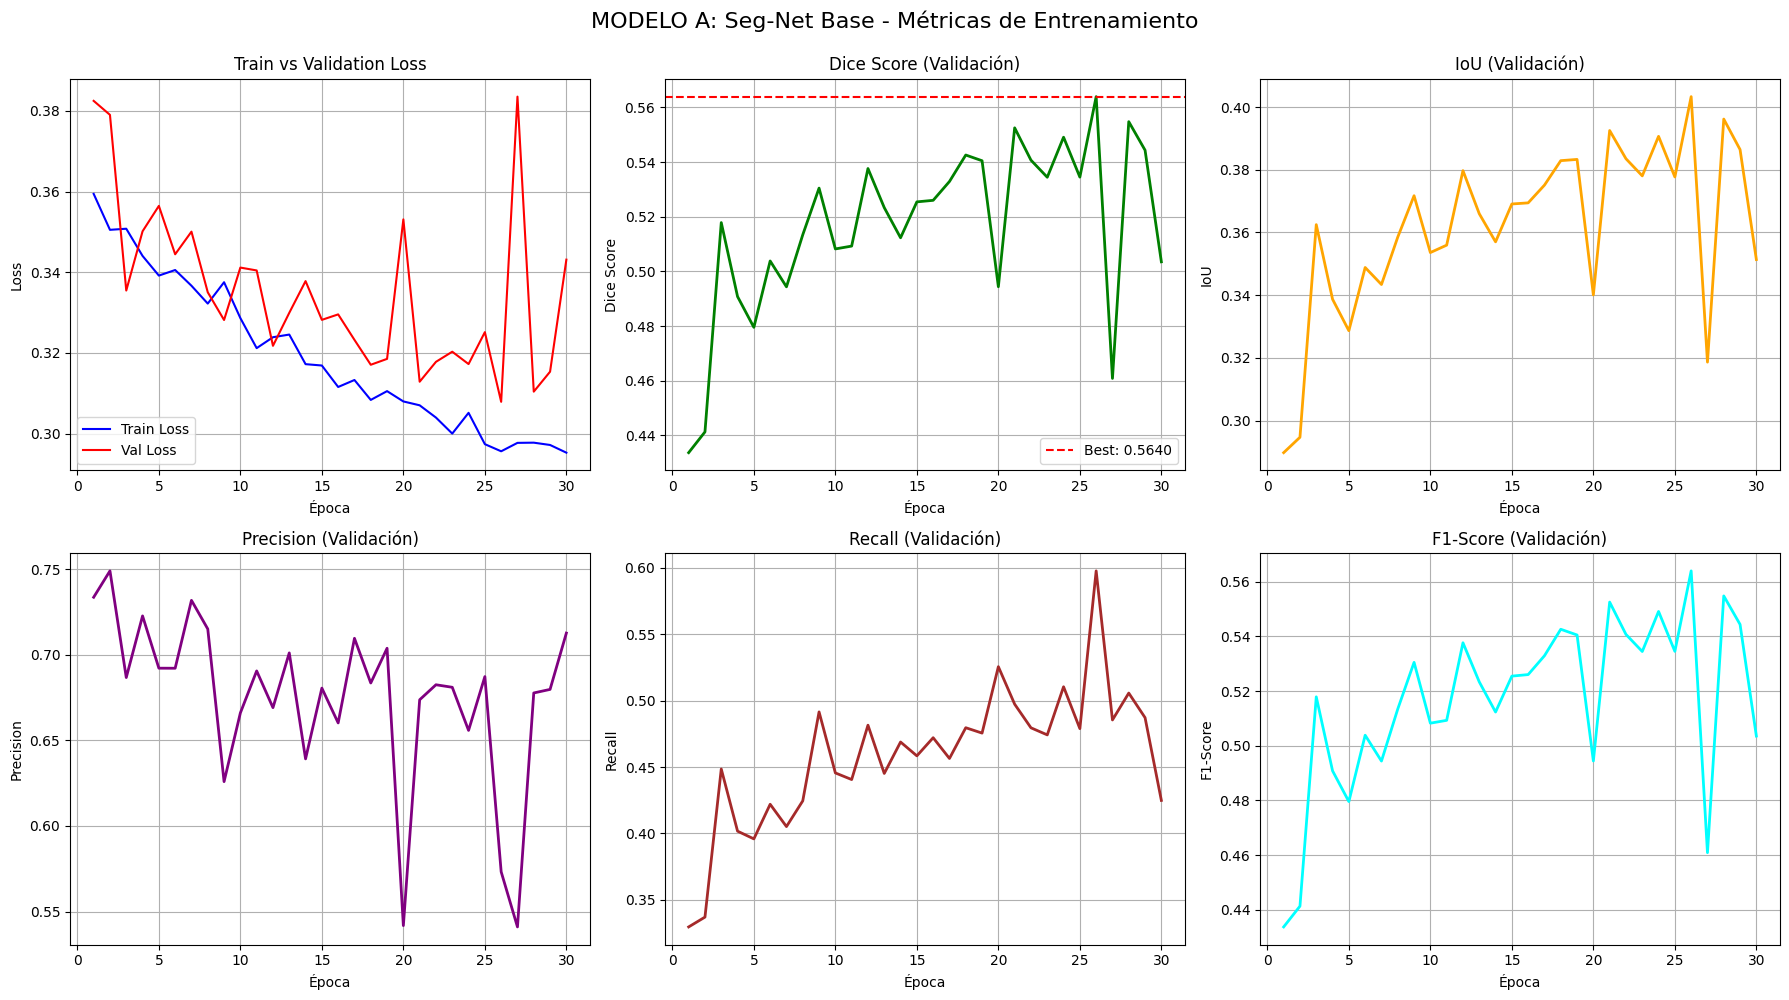

In [22]:
# Gráfico 1: Curvas de Loss
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice Score
axes[0, 1].plot(epochs_range, history['val_dice'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Dice Score')
axes[0, 1].set_title('Dice Score (Validación)')
axes[0, 1].grid(True)
axes[0, 1].axhline(y=best_val_dice, color='r', linestyle='--', 
                   label=f'Best: {best_val_dice:.4f}')
axes[0, 1].legend()

# IoU
axes[0, 2].plot(epochs_range, history['val_iou'], 'orange', linewidth=2)
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('IoU')
axes[0, 2].set_title('IoU (Validación)')
axes[0, 2].grid(True)

# Precision
axes[1, 0].plot(epochs_range, history['val_precision'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision (Validación)')
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(epochs_range, history['val_recall'], 'brown', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall (Validación)')
axes[1, 1].grid(True)

# F1-Score
axes[1, 2].plot(epochs_range, history['val_f1'], 'cyan', linewidth=2)
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('F1-Score')
axes[1, 2].set_title('F1-Score (Validación)')
axes[1, 2].grid(True)

plt.suptitle('MODELO A: Seg-Net Base - Métricas de Entrenamiento', fontsize=16, y=0.995)
plt.tight_layout()
# plt.savefig('unet_base_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Gráfico de curvas guardado: unet_base_training_curves.png")

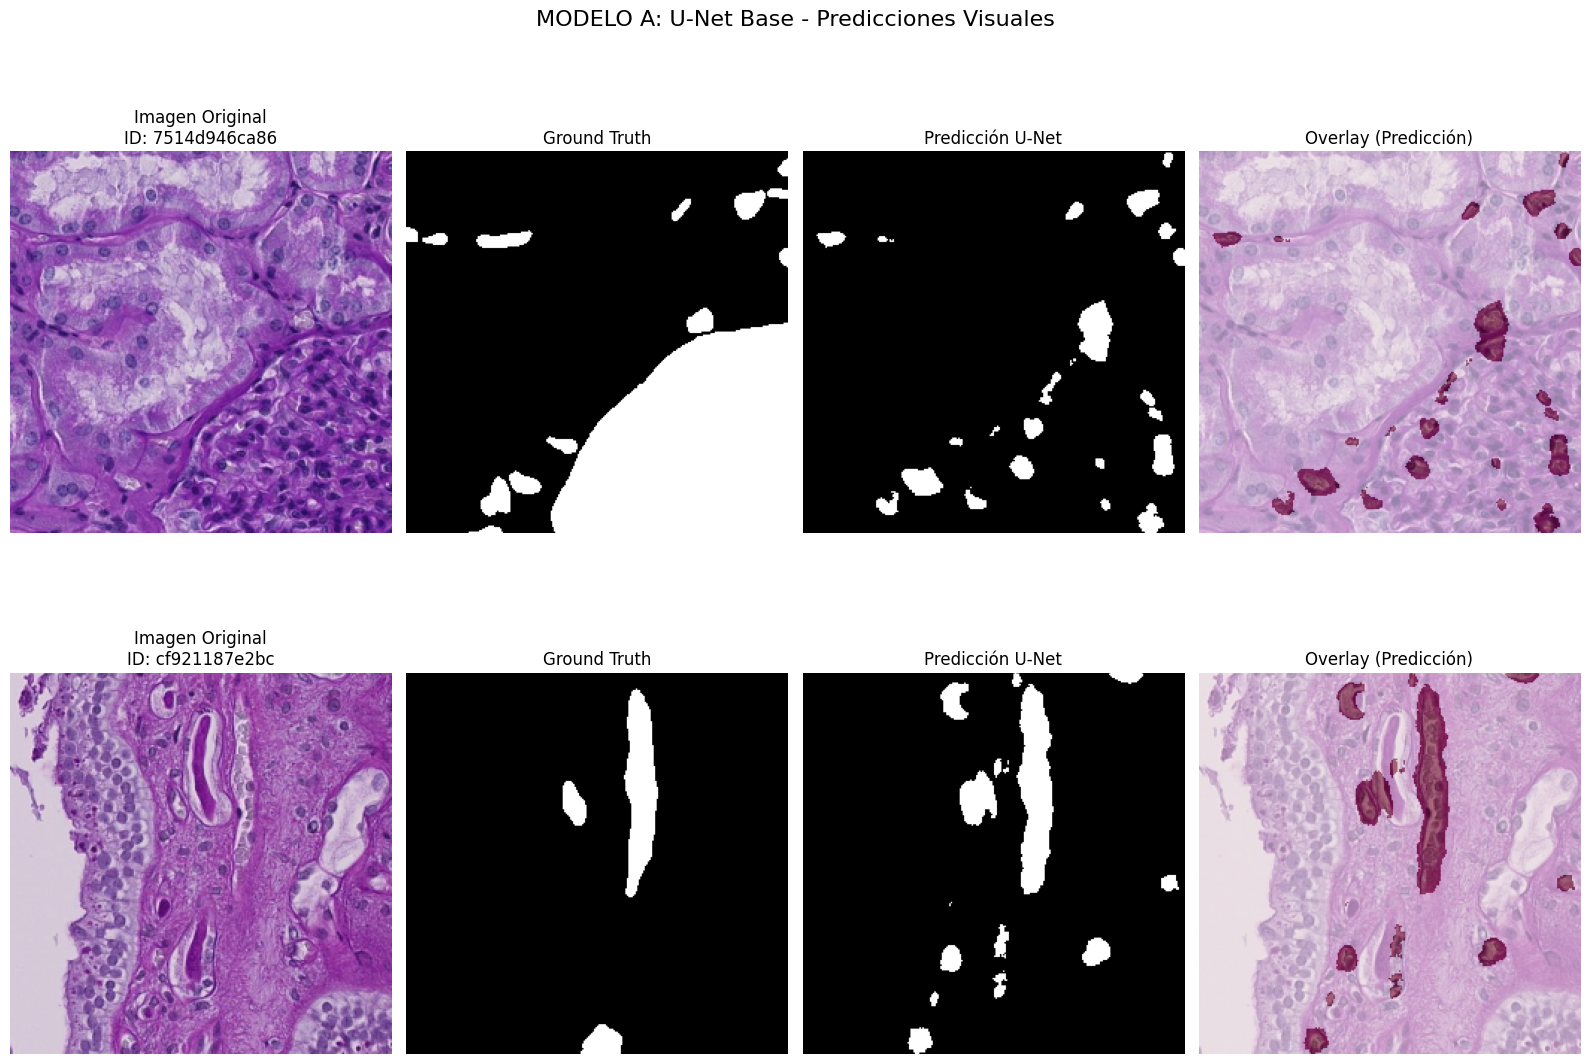

In [23]:
# Cargar mejor modelo
checkpoint = torch.load('best_segnet_base.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(16, 12))

with torch.no_grad():
    images, masks, tile_ids = next(iter(val_loader))
    images_gpu = images.to(device)
    outputs = model(images_gpu)
    predictions = torch.argmax(outputs, dim=1).cpu()
    
    for i in range(2):
        # Desnormalizar imagen
        img = images[i].numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        mask_gt = masks[i].numpy()
        mask_pred = predictions[i].numpy()
        
        # Imagen original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Imagen Original\nID: {tile_ids[i]}')
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(mask_gt, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Predicción
        axes[i, 2].imshow(mask_pred, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title('Predicción U-Net')
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(mask_pred, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title('Overlay (Predicción)')
        axes[i, 3].axis('off')

plt.suptitle('MODELO A: U-Net Base - Predicciones Visuales', fontsize=16)
plt.tight_layout()
# plt.savefig('unet_base_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Gráfico de predicciones guardado: unet_base_predictions.png")